In [1]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt

from Utils import *
from Network import *

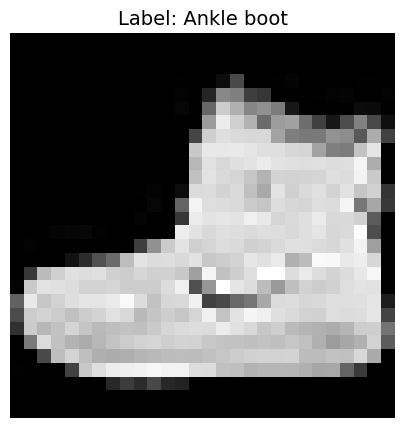

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


plt.figure(figsize=(5, 5))
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {class_names[y_train[0]]}", fontsize=14)
plt.axis('off')
plt.show()

x_train = x_train.astype("float32") / 255
x_test  = x_test.astype("float32") / 255

# one-hot 
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


x_train = x_train.reshape(-1, 1, 28, 28)
x_test  = x_test.reshape(-1, 1, 28, 28)

y_train = y_train.reshape(-1, 10, 1)
y_test  = y_test.reshape(-1, 10, 1)


# print(f"Training: {x_train.shape}, Labels: {y_train.shape}")
# print(f"Test: {x_test.shape}, Labels: {y_test.shape}")

In [3]:
network = Network([
    Convolutional((1, 28, 28), 3, 5),
    Relu(),
    Reshape((5, 26, 26), (5 * 26 * 26, 1)),
    Dense(5 * 26 * 26, 100),
    Relu(),
    Dense(100, 10),   
    Softmax()
])

In [4]:
network.train(
    categorical_cross_entropy,
    categorical_cross_entropy_prime,
    x_train,
    y_train,
    epochs=10,
    learning_rate=0.1
)

network.save("mnist_model.pkl")

1/10, error=0.429859
2/10, error=0.295264
3/10, error=0.243048
4/10, error=0.204584
5/10, error=0.173420
6/10, error=0.146107
7/10, error=0.124398
8/10, error=0.103899
9/10, error=0.088138
10/10, error=0.073389
Saved to mnist_model.pkl


In [5]:
# network = Network.load("mnist_model.pkl")

In [6]:
correct = 0
total = len(x_test)

for x, y in zip(x_test, y_test):
    output = network.predict(x)
    if np.argmax(output) == np.argmax(y):
        correct += 1

accuracy = correct / total * 100
print(f"Accuracy: {correct}/{total} = {accuracy:.2f}%")

Accuracy: 8981/10000 = 89.81%


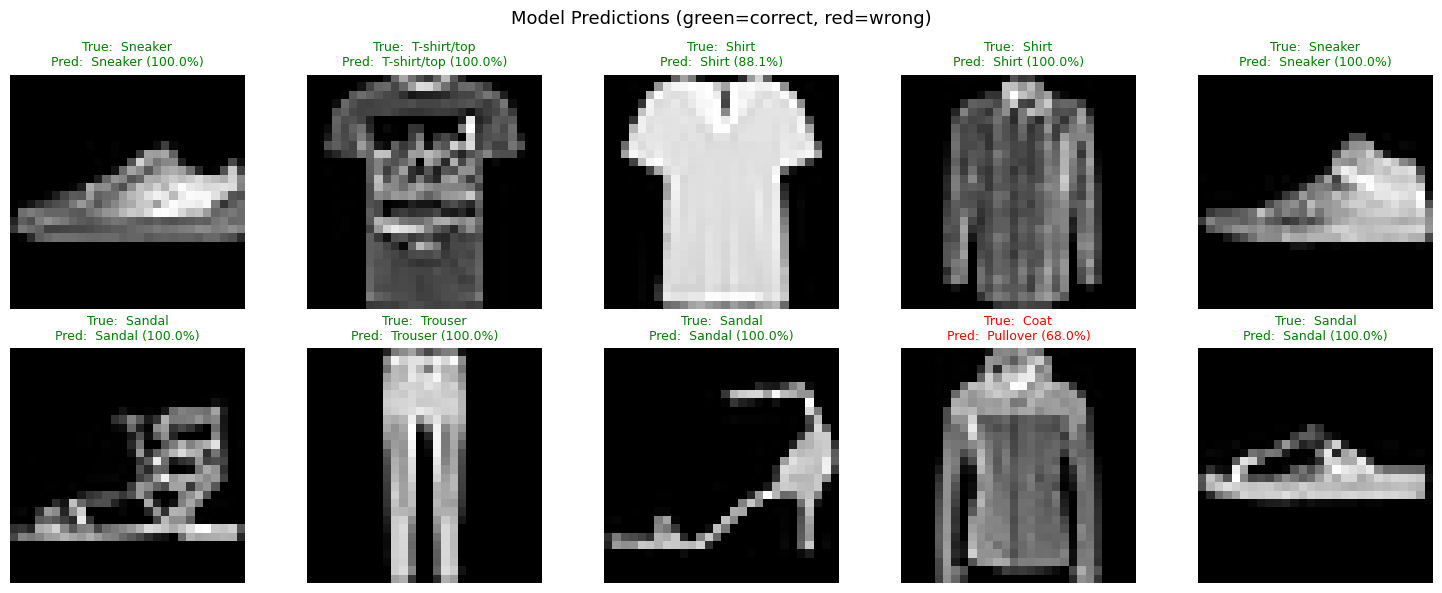

In [7]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

indices = random.sample(range(len(x_test)), 10)

for i, idx in enumerate(indices):
    x = x_test[idx]        # (1, 28, 28)
    y = y_test[idx]      

    output = network.predict(x) 

    true_label  = class_names[np.argmax(y)]
    pred_label  = class_names[np.argmax(output)]
    confidence  = np.max(output) * 100
    correct     = true_label == pred_label

    axes[i].imshow(x[0], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(
        f"True:  {true_label}\nPred:  {pred_label} ({confidence:.1f}%)",
        fontsize=9,
        color='green' if correct else 'red'
    )

plt.suptitle("Model Predictions (green=correct, red=wrong)", fontsize=13)
plt.tight_layout()
plt.show()